## Personal notebook for Logistic Regression by Jenna Kiviaho

### For this notebook the cleaned_100k.csv was used. The same skeleton from the main notebook was copied to ensure the same pipeline for the results comparison.

**Workflow**
1. Importing needed libraries
2. Data reading and splitting (copied from main notebook)
3. Creating skeleton (copied from main notebook)
4. Creating method for MinMaxScaler using the same formula as skeleton has
7. Running the model with multiple different setups (etc. No PCA and only SMOTE, using PCA but not SMOTE)
8. Testing the effect of MinMaxScaler


### Imports

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline          # NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                             ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
import seaborn as sns

### Reading sampled csv and splitting data 60/20/20

In [32]:
df = pd.read_csv("cleaned_100k.csv", low_memory=False)

y = df["Attack Type"]
X = df.drop("Attack Type", axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, random_state=42, stratify=y_train_val)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (60000, 52) Val: (20000, 52) Test: (20000, 52)


### Creating skeleton

In [33]:
# ---- Agreed 10-feature list ------------------------------------------
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 5
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True):
    """Fit Pipeline+GridSearchCV and return a results dict."""
    steps = [("scaler", StandardScaler())]
    steps.append(("pca",   PCA() if use_pca else "passthrough"))
    steps.append(("smote", SMOTE(random_state=42) if use_smote else "passthrough"))
    steps.append(("clf",   clf))
    pipe = Pipeline(steps)

    grid = GridSearchCV(pipe, param_grid=param_grid,
                        cv=CV_FOLDS, scoring=SCORING,
                        n_jobs=N_JOBS, verbose=1)
    grid.fit(X_train_sel, y_train)

    y_val_pred  = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc  = accuracy_score(y_val,  y_val_pred)
    val_f1   = f1_score(y_val, y_val_pred, average="macro")
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="macro")

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{label} — test confusion matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params :", grid.best_params_)
    print(f"Val  acc={val_acc:.4f}  f1_macro={val_f1:.4f}")
    print(f"Test acc={test_acc:.4f}  f1_macro={test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label":         label,
        "best_params":   grid.best_params_,
        "val_acc":       val_acc,
        "val_f1_macro":  val_f1,
        "test_acc":      test_acc,
        "test_f1_macro": test_f1,
        "smote":         use_smote,
        "pca":           use_pca,
    }

all_results = []

### Creating minmaxscaler method

In [34]:
from sklearn.preprocessing import MinMaxScaler

# Creating method for the minmaxscaler
# Purpose is to see if it affects the results
def run_experiment_minmax(clf, param_grid, label, use_smote=True, use_pca=True):
    """Fit Pipeline+GridSearchCV and return a results dict."""
    steps = [("scaler", MinMaxScaler())]
    steps.append(("pca",   PCA() if use_pca else "passthrough"))
    steps.append(("smote", SMOTE(random_state=42) if use_smote else "passthrough"))
    steps.append(("clf",   clf))
    pipe = Pipeline(steps)

    grid = GridSearchCV(pipe, param_grid=param_grid,
                        cv=CV_FOLDS, scoring=SCORING,
                        n_jobs=N_JOBS, verbose=1)
    grid.fit(X_train_sel, y_train)

    y_val_pred  = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc  = accuracy_score(y_val,  y_val_pred)
    val_f1   = f1_score(y_val, y_val_pred, average="macro")
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="macro")

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{label} — test confusion matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params :", grid.best_params_)
    print(f"Val  acc={val_acc:.4f}  f1_macro={val_f1:.4f}")
    print(f"Test acc={test_acc:.4f}  f1_macro={test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label":         label,
        "best_params":   grid.best_params_,
        "val_acc":       val_acc,
        "val_f1_macro":  val_f1,
        "test_acc":      test_acc,
        "test_f1_macro": test_f1,
        "smote":         use_smote,
        "pca":           use_pca,
    }

### Running the model without SMOTE and scaling

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


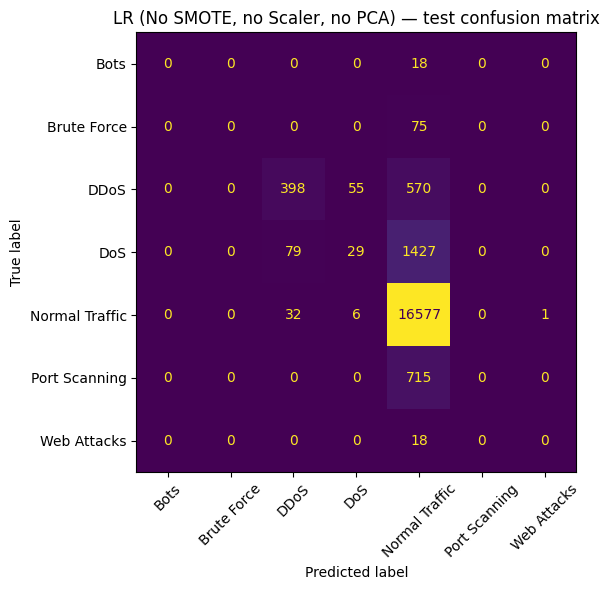


=== LR (No SMOTE, no Scaler, no PCA) ===
Best params : {'scaler': 'passthrough'}
Val  acc=0.8514  f1_macro=0.2145
Test acc=0.8502  f1_macro=0.2108
                precision    recall  f1-score   support

          Bots      0.000     0.000     0.000        18
   Brute Force      0.000     0.000     0.000        75
          DDoS      0.782     0.389     0.520      1023
           DoS      0.322     0.019     0.036      1535
Normal Traffic      0.854     0.998     0.921     16616
 Port Scanning      0.000     0.000     0.000       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.850     20000
     macro avg      0.280     0.201     0.211     20000
  weighted avg      0.775     0.850     0.794     20000



c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [35]:
baseline_model = all_results.append(run_experiment(
    LogisticRegression(max_iter=3000), 
    {'scaler': ['passthrough']}, # overwriting scaler
    "LR (No SMOTE, no Scaler, no PCA)", 
    use_smote=False, 
    use_pca=False))

### Running the model without scaler using SMOTE and PCA

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


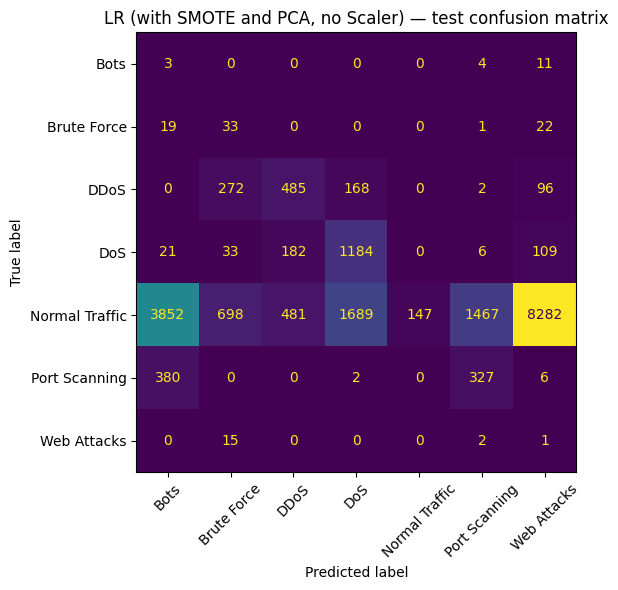


=== LR (with SMOTE and PCA, no Scaler) ===
Best params : {'scaler': 'passthrough'}
Val  acc=0.1071  f1_macro=0.1853
Test acc=0.1090  f1_macro=0.1859
                precision    recall  f1-score   support

          Bots      0.001     0.167     0.001        18
   Brute Force      0.031     0.440     0.059        75
          DDoS      0.422     0.474     0.447      1023
           DoS      0.389     0.771     0.517      1535
Normal Traffic      1.000     0.009     0.018     16616
 Port Scanning      0.181     0.457     0.259       715
   Web Attacks      0.000     0.056     0.000        18

      accuracy                          0.109     20000
     macro avg      0.289     0.339     0.186     20000
  weighted avg      0.889     0.109     0.087     20000



In [36]:
model_no_scaler = all_results.append(run_experiment(
    LogisticRegression(max_iter=3000), 
    {'scaler': ['passthrough']}, # overwriting scaler
    "LR (with SMOTE and PCA, no Scaler)", 
    use_smote=True, 
    use_pca=True))

#### **Conclusions**

Without scaling and SMOTE the model predicts 85% as "Normal Traffic", because the data is imbalanced. Also F1-macro is only 21%, which means that this model can't predict most of the Attack Types. Using SMOTE and PCA without scaling leads to misleading results. F1-macro decreased even more from 21% to 18% which highlights the critical role of scaling.

Max iterations were between 1000 and 3000 but the model still reached the number of iterations limit. Features have large difference in degree so this proves that StandardScaler is necessary for Logistic Regression so we can find a solution in descent amount of time.

### Running the model with SMOTE and scaling

Fitting 5 folds for each of 6 candidates, totalling 30 fits


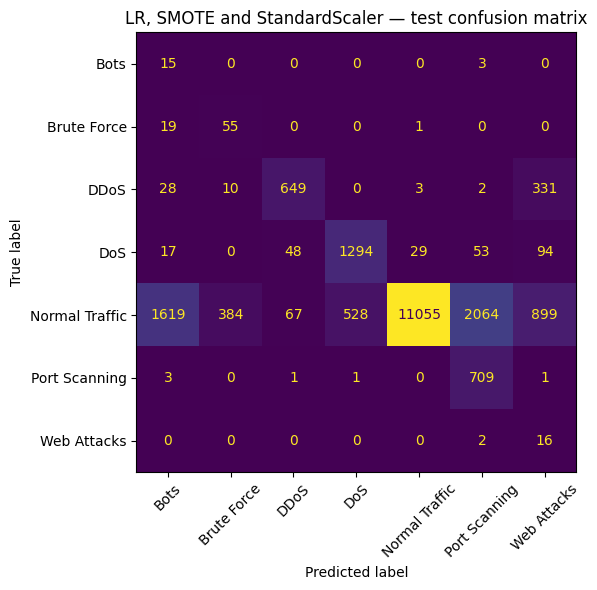


=== LR, SMOTE and StandardScaler ===
Best params : {'clf__C': 10.0, 'pca__n_components': 8}
Val  acc=0.6911  f1_macro=0.4211
Test acc=0.6896  f1_macro=0.4208
                precision    recall  f1-score   support

          Bots      0.009     0.833     0.017        18
   Brute Force      0.122     0.733     0.210        75
          DDoS      0.848     0.634     0.726      1023
           DoS      0.710     0.843     0.771      1535
Normal Traffic      0.997     0.665     0.798     16616
 Port Scanning      0.250     0.992     0.400       715
   Web Attacks      0.012     0.889     0.024        18

      accuracy                          0.690     20000
     macro avg      0.421     0.799     0.421     20000
  weighted avg      0.936     0.690     0.774     20000



In [37]:
# Parameters
lr_params = {
    'clf__C': [0.1, 1.0, 10.0],
    'pca__n_components': [5, 8]
}

# Running test (using the function created above)
# SMOTE and StandardScaler + PCA
model = all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs'), 
    lr_params, "LR, SMOTE and StandardScaler"))

### Running the model using SMOTE but no PCA

Fitting 5 folds for each of 3 candidates, totalling 15 fits


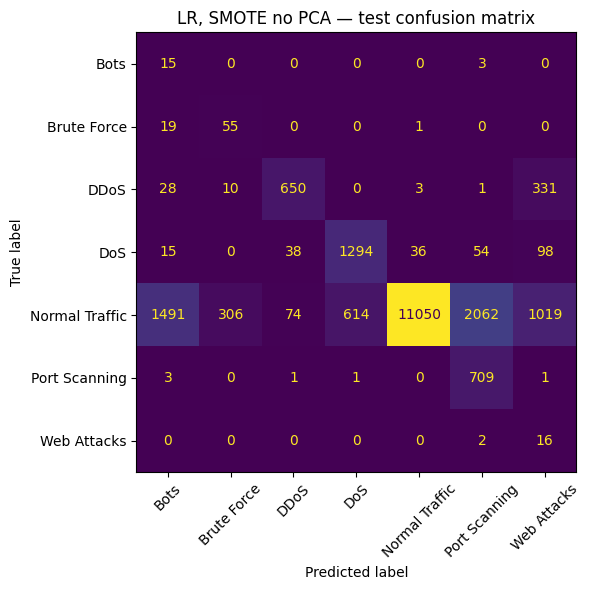


=== LR, SMOTE no PCA ===
Best params : {'clf__C': 10.0}
Val  acc=0.6904  f1_macro=0.4249
Test acc=0.6895  f1_macro=0.4234
                precision    recall  f1-score   support

          Bots      0.010     0.833     0.019        18
   Brute Force      0.148     0.733     0.247        75
          DDoS      0.852     0.635     0.728      1023
           DoS      0.678     0.843     0.751      1535
Normal Traffic      0.996     0.665     0.798     16616
 Port Scanning      0.250     0.992     0.400       715
   Web Attacks      0.011     0.889     0.022        18

      accuracy                          0.689     20000
     macro avg      0.421     0.799     0.423     20000
  weighted avg      0.933     0.689     0.773     20000



In [38]:
lr_params_no_pca = {
    'clf__C': [0.1, 1.0, 10.0]
}

model_no_pca = all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs'), 
    lr_params_no_pca, "LR, SMOTE no PCA", use_pca=False))

### Running the model without SMOTE and using PCA

Fitting 5 folds for each of 6 candidates, totalling 30 fits


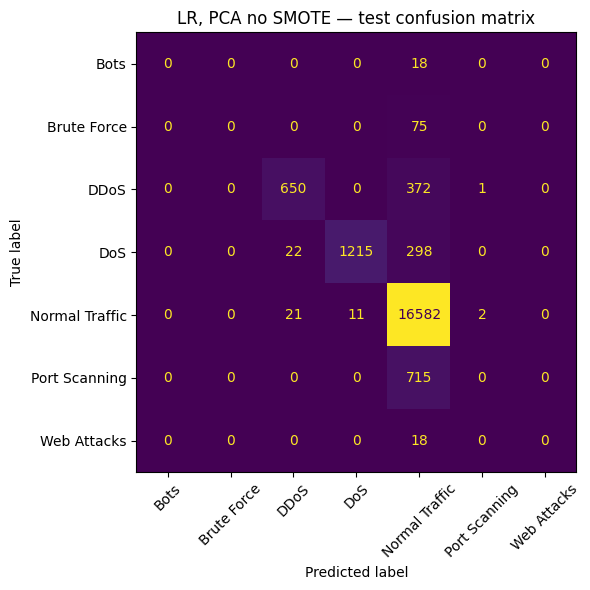


=== LR, PCA no SMOTE ===
Best params : {'clf__C': 10.0, 'pca__n_components': 8}
Val  acc=0.9245  f1_macro=0.3741
Test acc=0.9224  f1_macro=0.3705
                precision    recall  f1-score   support

          Bots      0.000     0.000     0.000        18
   Brute Force      0.000     0.000     0.000        75
          DDoS      0.938     0.635     0.758      1023
           DoS      0.991     0.792     0.880      1535
Normal Traffic      0.917     0.998     0.956     16616
 Port Scanning      0.000     0.000     0.000       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.922     20000
     macro avg      0.407     0.346     0.371     20000
  weighted avg      0.886     0.922     0.900     20000



c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [39]:
model_no_smote = all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs'), 
    lr_params, "LR, PCA no SMOTE", use_smote=False))

#### **Conclusions**

Running the Logistic Regression using the skeleton which has scaling and SMOTE changed the accuracy from 85% to 69%. Even though the overall accuracy is lower, after SMOTE the model predicts around 83% of Bots and 99% of Port Scanning attacks correctly. F1-macro increased from 21% to 42% with scaling and SMOTE so this model doubled the performance. Use of PCA didn't have remarkable affect on model's performance.

Although with SMOTE and scaling it has false alarms and it predicts some of Normal Traffic as attacks, it is more valuable to distinguish the actual attacks more accurately for security.

### Testing the effect of MinMaxScaler

Fitting 5 folds for each of 6 candidates, totalling 30 fits


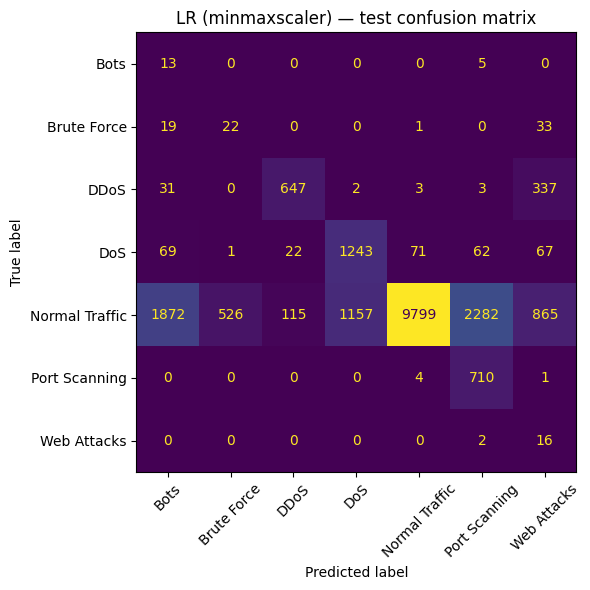


=== LR (minmaxscaler) ===
Best params : {'clf__C': 10.0, 'pca__n_components': 8}
Val  acc=0.6267  f1_macro=0.3733
Test acc=0.6225  f1_macro=0.3672
                precision    recall  f1-score   support

          Bots      0.006     0.722     0.013        18
   Brute Force      0.040     0.293     0.071        75
          DDoS      0.825     0.632     0.716      1023
           DoS      0.517     0.810     0.631      1535
Normal Traffic      0.992     0.590     0.740     16616
 Port Scanning      0.232     0.993     0.376       715
   Web Attacks      0.012     0.889     0.024        18

      accuracy                          0.623     20000
     macro avg      0.375     0.704     0.367     20000
  weighted avg      0.915     0.623     0.713     20000



In [40]:
# Testing with minmaxscaler (using seperately created method)
model_minmax = all_results.append(run_experiment_minmax
                                  (LogisticRegression(max_iter=2000, solver='lbfgs'),
                                    lr_params, "LR (minmaxscaler)"))

#### **Conclusions**

MinMaxScaler performed worse than StandardScaler. Overall accuracy decreased to around 62% when the StandardScaler had 69%. Also the recall for Brute Force and Bots decreased significantly. This is probably due to outliers and StandardScaler handles them more stable.

In [41]:
import pandas as pd
# Tämä näyttää nyt kaikki ajot hienossa taulukossa
df_results = pd.DataFrame(all_results)
display(df_results)

,label,best_params,val_acc,val_f1_macro,test_acc,test_f1_macro,smote,pca
0,"LR (No SMOTE, no Scaler, no PCA)",{'scaler': 'passthrough'},0.85135,0.214539,0.85020,0.210830,False,False
1,"LR (with SMOTE and PCA, no Scaler)",{'scaler': 'passthrough'},0.10710,0.185278,0.10900,0.185850,True,True
2,"LR, SMOTE and StandardScaler","{'clf__C': 10.0, 'pca__n_components': 8}",0.69110,0.421094,0.68965,0.420759,True,True
3,"LR, SMOTE no PCA",{'clf__C': 10.0},0.69035,0.424908,0.68945,0.423425,True,False
4,"LR, PCA no SMOTE","{'clf__C': 10.0, 'pca__n_components': 8}",0.92450,0.374131,0.92235,0.370513,False,True
5,LR (minmaxscaler),"{'clf__C': 10.0, 'pca__n_components': 8}",0.62670,0.373297,0.62250,0.367190,True,True
